In [1]:
import scanpy as sc


brca_cell_adata = sc.read_h5ad("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/brca_cellabundance/brca_cellabundance_estimation.h5ad")
brca_cell_adata

AnnData object with n_obs × n_vars = 880 × 13199
    obs: '_indices', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'stds_cell_abundance_w_sf'

In [2]:
brca_cell_label_df = brca_cell_adata.obsm['q05_cell_abundance_w_sf']
brca_cell_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-A8-A09R-01Z-00-DX1,0.002925,0.002420,0.010768,0.0259,0.045246,0.222976,0.024620,0.336438,0.060828,2.076841,...,0.006568,0.022835,0.065895,0.043894,0.131588,0.041848,0.070641,0.003808,0.631248,0.011149
TCGA-E2-A1IE-01Z-00-DX1,0.000710,0.000151,0.000354,0.0040,0.001229,0.003494,0.000591,0.000251,0.048617,0.182926,...,0.000041,0.000068,0.000024,0.000088,0.058550,0.000005,0.000034,0.000007,0.632732,0.040799


In [3]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]

from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/data/brca/*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('/')[-1]
    test_slides.append(tif_path)
test_slides[:2]

['TCGA-3C-AALK-01Z-00-DX1', 'TCGA-4H-AAAK-01Z-00-DX1']

In [4]:
import joblib
from tqdm import tqdm


pred_id_mena_dict = dict()        
for case in tqdm(test_slides):
    # os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case))
    try:
        save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/brca/breast_cross_source_epoch100_lr1e-4_2hop_ensemble_Trans1layer_GNNoutput50_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
        pred_and_label = joblib.load(save_path)
        pred_id_mena_dict[case] = pred_and_label['cell_abundance_predictions'].mean(axis=0)
    except:
        continue

100%|██████████| 826/826 [00:00<00:00, 3254.06it/s]


In [5]:
len(pred_id_mena_dict)

585

In [6]:
pred_id_mena_dict.keys()

dict_keys(['TCGA-3C-AALK-01Z-00-DX1', 'TCGA-4H-AAAK-01Z-00-DX1', 'TCGA-5L-AAT1-01Z-00-DX1', 'TCGA-5T-A9QA-01Z-00-DX1', 'TCGA-A1-A0SK-01Z-00-DX1', 'TCGA-A2-A04N-01Z-00-DX1', 'TCGA-A2-A04P-01Z-00-DX1', 'TCGA-A2-A04R-01Z-00-DX1', 'TCGA-A2-A04T-01Z-00-DX1', 'TCGA-A2-A04U-01Z-00-DX1', 'TCGA-A2-A04W-01Z-00-DX1', 'TCGA-A2-A04X-01Z-00-DX1', 'TCGA-A2-A0CK-01Z-00-DX1', 'TCGA-A2-A0CM-01Z-00-DX1', 'TCGA-A2-A0CP-01Z-00-DX1', 'TCGA-A2-A0CQ-01Z-00-DX1', 'TCGA-A2-A0CR-01Z-00-DX1', 'TCGA-A2-A0CT-01Z-00-DX1', 'TCGA-A2-A0CU-01Z-00-DX1', 'TCGA-A2-A0CX-01Z-00-DX1', 'TCGA-A2-A0CY-01Z-00-DX1', 'TCGA-A2-A0CZ-01Z-00-DX1', 'TCGA-A2-A0D0-01Z-00-DX1', 'TCGA-A2-A0D4-01Z-00-DX1', 'TCGA-A2-A0EN-01Z-00-DX1', 'TCGA-A2-A0EO-01Z-00-DX1', 'TCGA-A2-A0EQ-01Z-00-DX1', 'TCGA-A2-A0ER-01Z-00-DX1', 'TCGA-A2-A0ET-01Z-00-DX1', 'TCGA-A2-A0EU-01Z-00-DX1', 'TCGA-A2-A0EV-01Z-00-DX1', 'TCGA-A2-A0EW-01Z-00-DX1', 'TCGA-A2-A0EY-01Z-00-DX1', 'TCGA-A2-A0ST-01Z-00-DX1', 'TCGA-A2-A0SU-01Z-00-DX1', 'TCGA-A2-A0SV-01Z-00-DX1', 'TCGA-A2-A0SW-01Z

In [7]:
pred_id_mena_dict['TCGA-3C-AALK-01Z-00-DX1'].shape

(39,)

In [8]:
import numpy as np

pred_df_list = []
for case in pred_id_mena_dict.keys():
    pred_df = pd.DataFrame(data=np.expand_dims(pred_id_mena_dict[case], axis=0), columns=cell_names, index=[case])
    pred_df_list.append(pred_df)

In [9]:
pred_all_case_df = pd.concat(pred_df_list, join='inner')
pred_all_case_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-3C-AALK-01Z-00-DX1,0.160704,0.221731,0.105877,1.572897,1.550151,0.039653,0.158888,0.780631,0.042309,0.400047,...,0.13908,0.243357,0.274147,0.143055,0.099567,0.431812,0.253349,0.102376,0.796682,0.079286
TCGA-4H-AAAK-01Z-00-DX1,0.306479,0.564471,0.156112,0.888829,0.700434,-0.041915,0.277069,2.113774,0.079509,0.217030,...,0.26064,0.287138,0.191035,0.218524,0.158000,0.309171,0.649358,0.164299,0.600419,0.160729


In [10]:
label_idx_set = set(brca_cell_label_df.index)
pred_idx_set = set(pred_all_case_df.index)
selected_idx_set = label_idx_set.intersection(pred_idx_set)
len(selected_idx_set)

585

In [11]:
selected_idx_list = list(selected_idx_set)

In [12]:
seleted_label_df = brca_cell_label_df.loc[selected_idx_list, :]
seleted_label_df.head(2)

,q05cell_abundance_w_sf_CD4-positive helper T cell,"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",q05cell_abundance_w_sf_IgA plasma cell,q05cell_abundance_w_sf_IgG plasma cell,q05cell_abundance_w_sf_T cell,"q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell","q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell",q05cell_abundance_w_sf_alternatively activated macrophage,q05cell_abundance_w_sf_basal cell,...,q05cell_abundance_w_sf_naive B cell,q05cell_abundance_w_sf_natural killer cell,q05cell_abundance_w_sf_neutrophil,q05cell_abundance_w_sf_non-classical monocyte,q05cell_abundance_w_sf_pericyte,q05cell_abundance_w_sf_plasmacytoid dendritic cell,q05cell_abundance_w_sf_regulatory T cell,q05cell_abundance_w_sf_unswitched memory B cell,q05cell_abundance_w_sf_vascular associated smooth muscle cell,q05cell_abundance_w_sf_vein endothelial cell
TCGA-E9-A22G-01Z-00-DX1,0.000008,0.000023,0.000025,0.000001,0.000768,0.257118,0.000008,0.000015,0.000063,0.191216,...,0.000661,0.000005,0.000982,0.000009,0.115968,8.085347e-07,0.000010,0.023145,0.006379,0.024270
TCGA-AO-A1KP-01Z-00-DX1,0.000954,0.079544,0.001266,0.000608,0.001037,0.001857,0.001385,0.000487,0.004260,1.601676,...,0.001877,0.000024,0.007847,0.000078,0.070017,7.395473e-06,0.029328,0.000049,1.010214,0.065178


In [15]:
seleted_pred_df = pred_all_case_df.loc[selected_idx_list, :]
seleted_pred_df.head(2)

,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD8-positive, alpha-beta memory T cell",IgA plasma cell,IgG plasma cell,T cell,"activated CD4-positive, alpha-beta T cell","activated CD8-positive, alpha-beta T cell",alternatively activated macrophage,basal cell,...,naive B cell,natural killer cell,neutrophil,non-classical monocyte,pericyte,plasmacytoid dendritic cell,regulatory T cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
TCGA-E9-A22G-01Z-00-DX1,0.336434,0.659049,0.175903,1.989216,4.844073,0.045699,0.333006,3.076167,0.054257,0.149200,...,0.266944,0.774394,0.66388,0.403540,0.128332,1.038829,0.809376,0.174738,0.405263,0.209558
TCGA-AO-A1KP-01Z-00-DX1,0.218542,0.391391,0.106958,1.096781,1.624673,0.051482,0.181263,1.643693,0.065764,0.197077,...,0.169985,0.293933,0.26594,0.229607,0.097055,0.474187,0.478767,0.109004,0.746880,0.105911


In [14]:
normalized_seleted_pred_df = seleted_pred_df.apply(lambda row: row / row.sum(), axis=1)
normalized_seleted_label_df = seleted_label_df.apply(lambda row: row / row.sum(), axis=1)

In [15]:
from scipy.stats import pearsonr

test_cell_pearson_list = list()
test_cell_abundance_pos_pearson_average = 0.0
test_cell_abundance_all_pearson_average = 0.0
test_cell_abundance_pos_pearson_count = 0
for i in range(39):
    r, p = pearsonr(normalized_seleted_pred_df.iloc[:, i], normalized_seleted_label_df.iloc[:, i])
    if r > 0.0:
        test_cell_abundance_pos_pearson_count = test_cell_abundance_pos_pearson_count + 1
        test_cell_abundance_pos_pearson_average = test_cell_abundance_pos_pearson_average + r
    if np.isnan(r):
        r = 0.0
    test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average + r
    test_cell_pearson_list.append(r)
if test_cell_abundance_pos_pearson_count >= 1:
    test_cell_abundance_pos_pearson_average /= test_cell_abundance_pos_pearson_count
else:
    test_cell_abundance_pos_pearson_average = 0.0
test_cell_abundance_all_pearson_average = test_cell_abundance_all_pearson_average / 39

In [16]:
test_cell_abundance_pos_pearson_count

26

In [17]:
test_cell_abundance_pos_pearson_average

0.13489525980934008

In [18]:
test_cell_abundance_all_pearson_average

0.06331109350616097

In [19]:
test_cell_pearson_dict = dict()
for i in range(39):
    test_cell_pearson_dict[cell_names[i]] = test_cell_pearson_list[i]
test_cell_pearson_dict

{'CD4-positive helper T cell': -0.11193095873046023,
 'CD4-positive, alpha-beta T cell': 0.05304713238439321,
 'CD8-positive, alpha-beta memory T cell': 0.049370378316229285,
 'IgA plasma cell': -0.011784547102464895,
 'IgG plasma cell': -0.0650091901886138,
 'T cell': -0.03219448325806972,
 'activated CD4-positive, alpha-beta T cell': 0.07470682508400257,
 'activated CD8-positive, alpha-beta T cell': 0.16412952682574675,
 'alternatively activated macrophage': -0.15978022742651368,
 'basal cell': 0.12044029161702147,
 'capillary endothelial cell': 0.051171962190130135,
 'class switched memory B cell': 0.05365789768666824,
 'classical monocyte': -0.016321766831180563,
 'conventional dendritic cell': -0.027207944075229872,
 'effector memory CD4-positive, alpha-beta T cell': 0.01071102062169887,
 'effector memory CD8-positive, alpha-beta T cell': 0.09303558957334805,
 'endothelial cell of artery': 0.21233654869951143,
 'endothelial cell of lymphatic vessel': 0.32468682777286684,
 'fibrobl

In [23]:
seleted_label_df_column_sum = seleted_label_df.sum(axis=0)
seleted_label_df_column_sum

q05cell_abundance_w_sf_CD4-positive helper T cell                           20.047012
q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell                      67.553469
q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell               11.088328
q05cell_abundance_w_sf_IgA plasma cell                                      50.805477
q05cell_abundance_w_sf_IgG plasma cell                                     161.472248
q05cell_abundance_w_sf_T cell                                               76.679234
q05cell_abundance_w_sf_activated CD4-positive, alpha-beta T cell           108.786262
q05cell_abundance_w_sf_activated CD8-positive, alpha-beta T cell           266.151534
q05cell_abundance_w_sf_alternatively activated macrophage                  151.026409
q05cell_abundance_w_sf_basal cell                                          803.686101
q05cell_abundance_w_sf_capillary endothelial cell                          150.439888
q05cell_abundance_w_sf_class switched memory B cell   

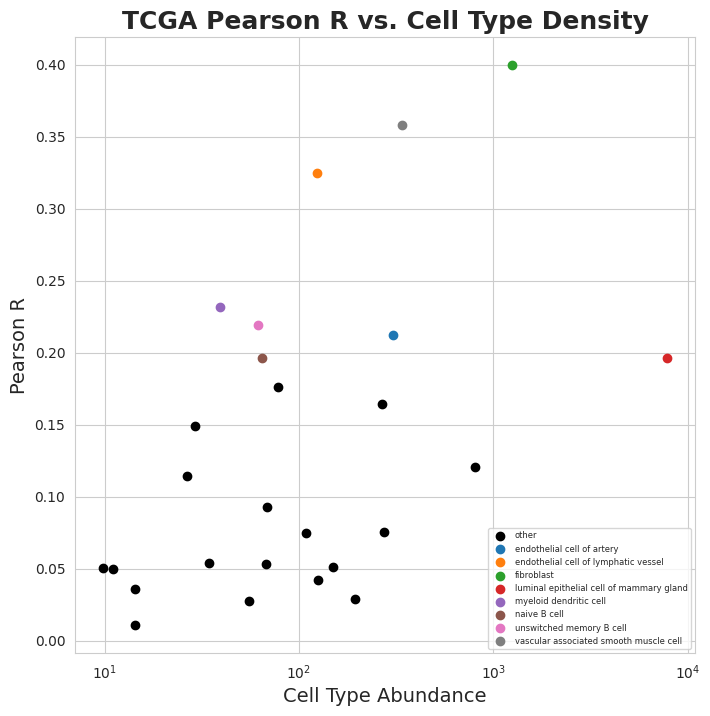

In [87]:
import matplotlib.pyplot as plt

density_list = seleted_label_df.sum(axis=0).tolist()
pearson_list = test_cell_pearson_list

# 过滤x轴大于2000的点
filtered_data = [(density, pearson, cell_name) for density, pearson, cell_name in zip(density_list, pearson_list, cell_names) if density < 10000 and pearson >= 0.]

# 将过滤后的数据分离为density和pearson两个列表
filtered_density_list, filtered_pearson_list, filterd_cell_name_list = zip(*filtered_data)

# Create a scatter plot
plt.figure(figsize=(8, 8))  # Set the figure size

# 使用过滤后的数据绘制散点图，并为每个点添加名称
other_label_added = False
for density, pearson, name in filtered_data:
    if pearson > 0.19:
        plt.scatter(x=density, y=pearson, label=name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=pearson, label="other", c="black")
            other_label_added = True
        else:
            plt.scatter(x=density, y=pearson, c="black")

# Set the title and axis labels
plt.title("TCGA Pearson R vs. Cell Type Density", fontsize=18, fontweight='bold')
plt.xlabel("Cell Type Abundance", fontsize=14)
plt.ylabel('Pearson R', fontsize=14)

# 设置X轴为对数坐标轴
plt.xscale('log')

# 显示图例
plt.legend(fontsize=6, loc='lower right')

# Show the plot
plt.show()

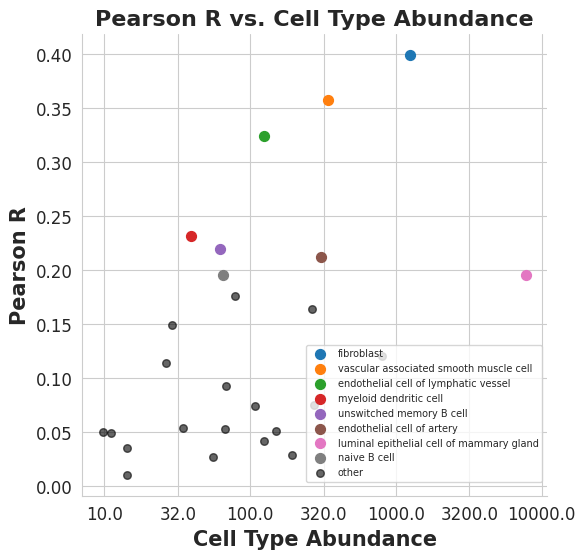

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style to a white background with a grid
sns.set_style("whitegrid")

# Filter the data to only include points with density less than 10,000 and Pearson coefficient greater than or equal to 0
filtered_data = [(density, pearson, cell_name) for density, pearson, cell_name in zip(density_list, pearson_list, cell_names) if density < 10000 and pearson >= 0.]

# Sort the filtered data by descending Pearson R values
filtered_data.sort(key=lambda x: x[1], reverse=True)

# Separate the filtered data into density and pearson lists
filtered_density_list, filtered_pearson_list, filtered_cell_name_list = zip(*filtered_data)

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size

# Use filtered data to draw the scatter plot, and add names for each point
other_label_added = False
for density, pearson, name in filtered_data:
    if pearson > 0.19:
        plt.scatter(x=density, y=pearson, label=name, s=50)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=pearson, label="other", c="black", s=30, alpha=0.6)
            other_label_added = True
        else:
            plt.scatter(x=density, y=pearson, c="black", s=30, alpha=0.6)

# Set the title and axis labels
plt.title("Pearson R vs. Cell Type Abundance", fontsize=16, fontweight='bold')
plt.xlabel("Cell Type Abundance", fontsize=15, fontweight='bold')
plt.ylabel('Pearson R', fontsize=15, fontweight='bold')

# Set the X-axis to a logarithmic scale
plt.xscale('log')

# Customize the ticks and labels for better readability
# Define the xticks and their labels
xticks = [1e1, 3.2e1, 1e2, 3.2e2, 1e3, 3.2e3, 1e4]
xtick_labels = [str(x) for x in xticks]

# Customize the ticks and labels for better readability
plt.xticks(xticks, xtick_labels, fontsize=12)
plt.yticks(fontsize=12)

# Display the legend
plt.legend(fontsize=7, loc='lower right', bbox_to_anchor=(1, 0.02))

# Remove the top and right spines for a cleaner look
sns.despine()

# Save the plot to a file
# plt.savefig("tcga_pearson_vs_density.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()